# 2. Batching, Load, and the Throughput–Latency Trade-off

By [Kiwan Maeng](https://kiwanmaeng.com) ([LinkedIn](https://www.linkedin.com/in/kiwan-maeng-23b825165)) and [Claude Code](https://claude.com/claude-code) 🤖

Lecture 1 showed that a lone decode step is **memory-bound**: each GPU streams
its half of the 65.5 GB of weights to produce a single token, while its math
units sit almost idle. Every serving system fixes this by **batching**: one
forward pass processes many requests at once, so each weight loaded from memory
is used for all of them.

This lecture asks two questions:

1. What does batching do to TTFT and TPOT, and how much throughput does it buy?
2. When requests arrive at random times, how much load can the system sustain
   before latency blows up?

:::{admonition} Learning goals
- Explain why batching prefills makes TTFT grow linearly, while batching decodes
  leaves TPOT almost unchanged.
- Explain when batching starts to see its limits.
- Explain why tail latency (p99) degrades before the median (p50), and define goodput.
:::

## Setup

Same setup as {doc}`01-prefill-and-decode`: Qwen2.5-32B-Instruct on two A100s.

In [1]:
import os, sys, urllib.request
sys.path.insert(0, os.path.abspath("../../labs"))
try:
    import llm_systems_wo_gpus as lsg
except ImportError:  # outside the course repo (e.g. Colab): fetch the package
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/kwmaeng91/studying-llm-systems-without-gpus/main/labs/llm_systems_wo_gpus.py",
        "llm_systems_wo_gpus.py")
    import llm_systems_wo_gpus as lsg
lsg.setup()

import matplotlib.pyplot as plt
import pandas as pd
plt.rcParams.update({"figure.figsize": (6, 3.5), "axes.grid": True, "grid.alpha": .3})

SYSTEM = dict(model="Qwen/Qwen2.5-32B-Instruct", device="a100", tensor_parallel=2)

Simulator ready at /home/user/.llm-systems-wo-gpus/backend


:::{warning}
**Unrealistic, but educational: prefill-only and decode-only requests.**

Real requests have both a prompt and an output, and real schedulers may mix them
(lecture 3 covers this). However, mixing prefill and decode complicates reasoning
and makes the behavior system-dependent. In this lecture, we simplify things for
educational purposes and make every request either prefill-only or decode-only:

- **prefill-only**: a normal prompt, but only **1** output token (`decode_tokens=1`);
- **decode-only**: a **1-token** prompt (`prefill_tokens=1`), then a normal output.

No real workload looks like this.
:::

## Batching prefills

What happens if $B$ prefill-only requests with 512-token prompts arrive at the
same time? The scheduler caps how many tokens one forward pass may process (`chunk_size`, a
knob we meet properly in lecture 3). Here we raise it to 16,384 so that all $B$
prompts fit into **one** forward pass.

In [2]:
rows = []
for b in [1, 2, 4, 8, 16, 32]:
    r = lsg.simulate(**SYSTEM, qps=None, num_requests=b,
                     prefill_tokens=512, decode_tokens=1, chunk_size=16384)
    ttft = r.ttft.median()
    rows.append({"batch size": b, "TTFT (ms)": 1e3 * ttft,
                 "prefill throughput (tok/s)": b * 512 / ttft})
prefill = pd.DataFrame(rows).set_index("batch size")
prefill.round(0)

,TTFT (ms),prefill throughput (tok/s)
batch size,,
1,100.0,5140.0
2,178.0,5755.0
4,329.0,6225.0
8,646.0,6345.0
16,1285.0,6377.0
32,2488.0,6586.0


`qps=None` means all requests arrive at time 0. Every request in the batch gets
its first token at the same moment, when the shared forward pass ends.

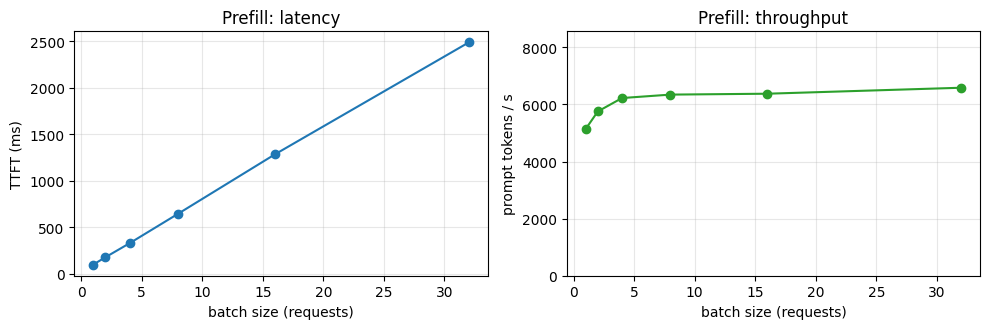

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
ax[0].plot(prefill.index, prefill["TTFT (ms)"], "o-")
ax[0].set(xlabel="batch size (requests)", ylabel="TTFT (ms)", title="Prefill: latency")
ax[1].plot(prefill.index, prefill["prefill throughput (tok/s)"], "o-", color="C2")
ax[1].set(xlabel="batch size (requests)", ylabel="prompt tokens / s", title="Prefill: throughput",
          ylim=(0, 1.3 * prefill["prefill throughput (tok/s)"].max()))
fig.tight_layout()

TTFT grows **linearly** with the batch size: each extra request adds about 80 ms.
Throughput improves only modestly (~30%), and almost all of that comes from going
from 1 to 4 requests, where a single 512-token prompt does not quite keep the GPUs
busy. This follows from lecture 1: prefill is already **compute-bound**. A batch
of $B$ prompts is simply $B$ times the arithmetic, and the GPUs were already busy
doing arithmetic, so there is little to gain.

## Batching decodes

Now let's see what happens when $B$ decode-only requests (256 output tokens each)
arrive together. Every forward pass produces one token for each of the $B$ requests.

In [4]:
rows = []
for b in [1, 2, 4, 8, 16, 32, 64, 128]:
    r = lsg.simulate(**SYSTEM, qps=None, num_requests=b, prefill_tokens=1, decode_tokens=256)
    rows.append({"batch size": b, "TPOT (ms)": 1e3 * r.tpot.median(),
                 "decode throughput (tok/s)": r.summary()["throughput (tok/s)"]})
decode = pd.DataFrame(rows).set_index("batch size")
decode.round(1)

,TPOT (ms),decode throughput (tok/s)
batch size,,
1,39.6,25.3
2,39.1,51.2
4,38.7,103.2
8,38.7,206.8
16,38.1,419.8
32,37.7,848.5
64,38.4,1665.0
128,41.7,3070.3


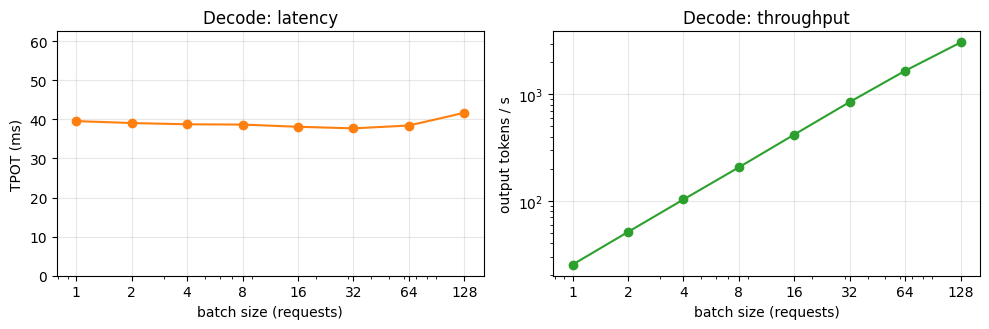

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
ax[0].plot(decode.index, decode["TPOT (ms)"], "o-", color="C1")
ax[0].set(xscale="log", xlabel="batch size (requests)", ylabel="TPOT (ms)", title="Decode: latency",
          ylim=(0, 1.5 * decode["TPOT (ms)"].max()))
ax[1].plot(decode.index, decode["decode throughput (tok/s)"], "o-", color="C2")
ax[1].set(xscale="log", yscale="log", xlabel="batch size (requests)", ylabel="output tokens / s",
          title="Decode: throughput")
for a in ax:
    a.set_xticks(decode.index, decode.index)
fig.tight_layout()

The opposite picture. TPOT stays at about 40 ms from 1 to 128 requests, while
throughput grows by more than 100×. Decode is **memory-bound**: each step loads
all the weights anyway, and the extra requests in the same batch reuse them almost
for free.
(The small dips and bumps in TPOT are noise from the simulator's fitted
runtime models, not a real effect.)

| | Batching prefills | Batching decodes |
|---|---|---|
| Latency | grows ~linearly with batch size | almost unchanged |
| Throughput | barely improves | grows ~linearly with batch size |
| Why | already compute-bound | memory-bound: weights shared by the batch |

:::{note}
What stops us from batching even more decodes? Every running request keeps its
KV cache in GPU memory. Here each token's KV cache takes
$2 \times 64\ \text{layers} \times 8\ \text{KV heads} \times 128 \times 2\ \text{B} = 256$ KB,
and after the weights the two GPUs have room for about 350,000 tokens. With
256-token requests, the scheduler's cap of 128 running requests binds first.
With long conversations, KV-cache memory becomes the limit.
:::

## Load: requests arriving over time

Real services don't receive requests in neat batches. They arrive at random
moments, and the scheduler adds each newcomer to the running batch as soon as
there is room (*continuous batching*). We model arrivals as a **Poisson
process** with rate `qps` (requests per second) and sweep the load, still using
decode-only requests with 256 output tokens.

In [6]:
loads = [1, 2, 4, 6, 8, 10, 11, 12, 13, 14, 16, 20]
online = lsg.sweep("qps", loads, **SYSTEM, num_requests=600, prefill_tokens=1, decode_tokens=256)
online[["TTFT p50 (ms)", "TTFT p99 (ms)", "TPOT p50 (ms)", "throughput (tok/s)"]].round(1)

,TTFT p50 (ms),TTFT p99 (ms),TPOT p50 (ms),throughput (tok/s)
qps,,,,
1.0,62.2,81.6,38.5,271.2
2.0,59.2,79.0,36.4,533.5
4.0,59.0,80.3,37.2,1033.8
6.0,65.1,87.8,41.0,1500.2
8.0,66.0,89.0,42.1,1934.0
10.0,68.4,371.8,43.1,2339.2
11.0,816.8,2165.7,43.8,2475.7
12.0,2752.2,5681.9,43.8,2499.8
13.0,4230.8,8604.6,43.7,2523.4


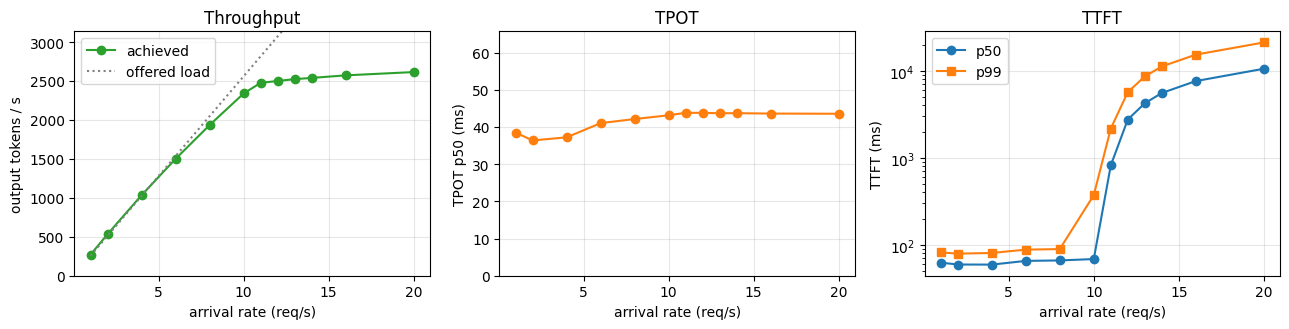

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))
ax[0].plot(online.index, online["throughput (tok/s)"], "o-", color="C2", label="achieved")
ax[0].plot(online.index, online.index * 256, ":", color="gray", label="offered load")
ax[0].set(xlabel="arrival rate (req/s)", ylabel="output tokens / s", title="Throughput",
          ylim=(0, 1.2 * online["throughput (tok/s)"].max()))
ax[0].legend()
ax[1].plot(online.index, online["TPOT p50 (ms)"], "o-", color="C1")
ax[1].set(xlabel="arrival rate (req/s)", ylabel="TPOT p50 (ms)", title="TPOT",
          ylim=(0, 1.5 * online["TPOT p50 (ms)"].max()))
ax[2].plot(online.index, online["TTFT p50 (ms)"], "o-", label="p50")
ax[2].plot(online.index, online["TTFT p99 (ms)"], "s-", label="p99")
ax[2].set(xlabel="arrival rate (req/s)", ylabel="TTFT (ms)", title="TTFT", yscale="log")
ax[2].legend()
fig.tight_layout()

Two regimes, with a sharp **knee** at about 10–11 requests per second:

- **Below the knee**, throughput increases linearly with the load, and TTFT and
  TPOT stay nearly flat. This is because every request that arrives immediately
  joins the batch, and as we saw above, adding more requests to a batch does not
  degrade TPOT much.
- **Past the knee**, throughput flattens and TTFT skyrockets. This is because the
  system cannot increase the batch size further, so requests wait in the queue to
  be served. There is no prefill (these are decode-only requests), but queueing
  alone increases TTFT: a new request cannot start until a prior request finishes
  and makes room for it.

### p99 degrades before p50

At 10 req/s, median TTFT is still ~70 ms, but p99 has already climbed to
several hundred milliseconds. Poisson arrivals come in **bursts**, and the
unlucky requests that land in a burst find the batch full and wait. A
service that promises a tail-latency target therefore has to run below its raw
capacity.

## Goodput: throughput that meets the SLO

TTFT and TPOT both matter, and each should meet its own target. For example,
TTFT is often said to need to stay below 200–500 ms so that users do not get
bored, and TPOT below 50–100 ms to keep up with a typical reading speed.
A common way to summarize this is **goodput**: the highest load at which
the service-level objective (SLO) still holds.

In [8]:
slo_ttft_ms, slo_tpot_ms = 500, 50
ok = online[(online["TTFT p99 (ms)"] < slo_ttft_ms) & (online["TPOT p99 (ms)"] < slo_tpot_ms)]
print(f"SLO: p99 TTFT < {slo_ttft_ms} ms and p99 TPOT < {slo_tpot_ms} ms")
print(f"Goodput: {ok.index.max()} req/s = {ok['throughput (tok/s)'].max():.0f} output tok/s, "
      f"vs. a raw capacity of ~{online['throughput (tok/s)'].max():.0f} tok/s")

SLO: p99 TTFT < 500 ms and p99 TPOT < 50 ms
Goodput: 10.0 req/s = 2339 output tok/s, vs. a raw capacity of ~2614 tok/s


## What's next: mixing prefill and decode

So far, every request was either all prefill or all decode. Real requests have
both, so a running batch constantly receives new prompts while other requests are
still decoding.

:::{admonition} Think about it
:class: exercise
What will happen if prefill and decode are mixed in the same batch? Think about
what a 4,000-token prompt does to the TPOT of the requests decoding next to it,
using what you measured above.
:::

The next lecture answers this question.

## Exercises

:::{admonition} Try it
:class: exercise
Each exercise asks you to change code above and rerun it. Write down your
prediction *before* you run.

1. **Shorter prompts.** In "Batching prefills", change the prompt length from
   512 to 128 tokens (both in `prefill_tokens=` and in the throughput formula) and
   rerun. Does batching prefills help more or less than before? Use what lecture 1
   said about prefill being compute-bound to explain why.
2. **Where is the knee?** At most 128 requests decode at once (the scheduler's
   batch-size cap), and each request needs `decode_tokens` steps of about one TPOT.
   From this, estimate the highest arrival rate the system can sustain with
   256-token outputs, and compare it with the knee in the load sweep. Then predict
   the knee, and check it by rerunning the sweep, for (a) `decode_tokens=128`, and
   (b) `batch_size_cap=64` (an argument of `lsg.sweep` and `lsg.simulate`).
3. **A stricter SLO.** In "Goodput", tighten the TPOT target from 50 ms to 40 ms
   and rerun. What happens to the goodput, and why does a 10 ms change in the
   target matter so much? Look at how TPOT p99 grows with the load.
:::

## Check your understanding

Click an answer to check it. Wrong answers can be retried.

In [9]:
#@title Questions (run this cell)
lsg.quiz([
    {"q": "You batch 8 prefill-only requests of the same length into one forward pass. Compared with a single request, their TTFT is about…",
     "options": ["the same", "2× longer", "8× longer"], "answer": 2,
     "explain": "Prefill is compute-bound, so 8 prompts take about 8 times the arithmetic."},
    {"q": "You batch 8 decode requests together. Compared with a single request, their TPOT is about…",
     "options": ["the same", "2× longer", "8× longer"], "answer": 0,
     "explain": "Decode is memory-bound. Each step loads the weights once and uses them for all 8 requests."},
    {"q": "Why is batching decodes so effective?",
     "options": ["It reduces the number of FLOPs per token",
                 "All requests in the batch share each load of the weights from memory",
                 "It makes the KV cache smaller"],
     "answer": 1,
     "explain": "The expensive part of a decode step is reading the weights; batching amortizes it over many requests."},
    {"q": "With long conversations, what usually limits how many requests can decode together?",
     "options": ["GPU FLOP/s", "GPU memory for the KV cache", "The number of CPU cores"],
     "answer": 1,
     "explain": "Every running request keeps its KV cache in GPU memory. Longer contexts mean fewer requests fit."},
    {"q": "The arrival rate passes the system's capacity. Which metric grows without bound?",
     "options": ["TPOT", "TTFT", "Both equally"], "answer": 1,
     "explain": "The running batch is full, so TPOT stays flat. New requests wait in the queue, and their TTFT keeps growing."},
    {"q": "Why does p99 TTFT rise before p50 TTFT as load increases?",
     "options": ["Random arrivals come in bursts, and requests in a burst have to wait",
                 "Long requests are always scheduled last",
                 "The simulator adds random noise to p99"],
     "answer": 0,
     "explain": "Even below capacity, bursts briefly fill the batch. The unlucky requests in them form the tail."},
    {"q": "What is goodput?",
     "options": ["The peak throughput of the GPU",
                 "The highest throughput at which the latency SLO is still met",
                 "Throughput measured with a batch size of 1"],
     "answer": 1,
     "explain": "Raw capacity is not useful if latency targets are missed. Goodput counts only throughput that meets the SLO."},
])